# 10_Model Evaluation and Generalization

# Model Evaluation and Generalization

지금까지 우리는 Data를 이용하여 Regression Model을 만들었다.

Model을 Training한 후에는 MSE와 $R^2$를 이용하여 Model의 성능을 평가하였다.

그러나 지금까지의 방법에는 중요한 문제가 있다.

> Model을 Training한 Data로 다시 Model을 평가해도 되는가?

이번 강의에서는 새로운 Data에 대해서도 좋은 Prediction을 하는 Model을 어떻게 선택하는지 알아본다.

## A Question from Polynomial Regression

09강에서는 Polynomial Degree를 증가시키면 더 복잡한 Curve를 표현할 수 있다는 것을 확인하였다.

예를 들어 다음과 같은 Models을 만들 수 있다.

Degree 1:

$$
\hat{y}=w_1x+b
$$

Degree 4:

$$
\hat{y}
=
w_1x+w_2x^2+w_3x^3+w_4x^4+b
$$

Degree 10:

$$
\hat{y}
=
w_1x+w_2x^2+\cdots+w_{10}x^{10}+b
$$

Degree를 계속 증가시키면 Training Data를 더 자세하게 따라갈 수 있다.

그렇다면 Training Error가 가장 작은 Model을 선택하면 될까?

In [1]:
from google.colab import drive

# Google Drive를 Colab에 Mount
drive.mount('/content/drive')

# 강의용 Data가 저장된 Folder

data_path = "/content/drive/My Drive/Colab Notebooks/0_ML/Input/"

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Data 읽기
df = pd.read_csv(data_path+"another2_data.csv")

X = df[["x"]]
y = df["y"]

display(df.head())

,x,y
0,-1.254599,4.817138
1,4.507143,10.890661
2,2.319939,2.683807
3,0.986585,5.544241
4,-3.439814,4.250485


## Training Error

먼저 지금까지 사용했던 방법으로 여러 Polynomial Models을 비교해 보자.

각 Model을 전체 Data로 Training하고 같은 Data에 대해 MSE를 계산한다.

이때 계산되는 Error를 Training Error라고 한다.

$$
\text{Training Data}
\rightarrow
\text{Training}
\rightarrow
\text{Evaluation}
$$

In [3]:
degrees = [1, 2, 3, 4, 5, 10]

train_errors = []

for degree in degrees:

    # Polynomial Features 생성
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_poly = poly.fit_transform(X)

    # Model Training
    model = LinearRegression()
    model.fit(X_poly, y)

    # Training Data Prediction
    y_pred = model.predict(X_poly)

    # Training Error
    mse = mean_squared_error(y, y_pred)

    train_errors.append(mse)

    print(f"Degree {degree}: MSE = {mse:.3f}")

Degree 1: MSE = 17.339
Degree 2: MSE = 14.930
Degree 3: MSE = 14.567
Degree 4: MSE = 2.055
Degree 5: MSE = 2.044
Degree 10: MSE = 2.010


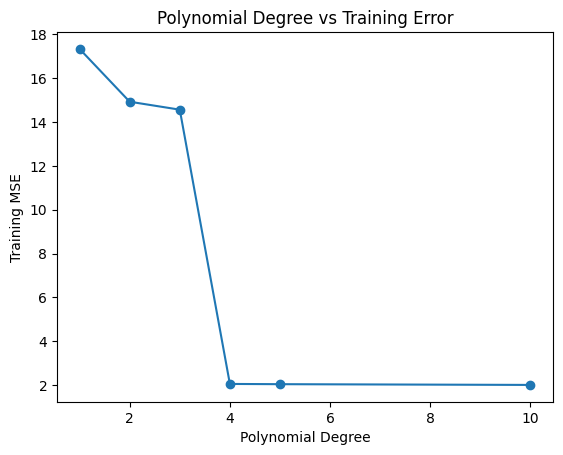

In [4]:
# Degree에 따른 Training Error
plt.plot(
    degrees,
    train_errors,
    marker="o"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Training MSE")
plt.title("Polynomial Degree vs Training Error")

plt.show()

## Is the Smallest Training Error the Best Model?

Degree가 증가하면 Model이 표현할 수 있는 Curve가 복잡해진다.

복잡한 Model은 Training Data의 세부적인 Pattern까지 따라갈 수 있다.

따라서 Training Error만 이용하면 높은 Degree의 Model이 더 좋아 보일 수 있다.

그러나 Machine Learning의 목적은 Training Data를 기억하는 것이 아니다.

우리가 원하는 것은 Training에 사용하지 않은 새로운 Data에 대해서도 좋은 Prediction을 하는 것이다.

따라서 Model Evaluation을 위한 Data를 따로 준비할 필요가 있다.

## Train Data and Test Data

전체 Data를 두 부분으로 나눈다.

Train Data:

Model의 Parameters를 학습하는 데 사용한다.

Test Data:

Training에 사용하지 않고 학습된 Model의 성능을 평가하는 데 사용한다.

$$
Data
\rightarrow
\begin{cases}
Train\ Data \rightarrow Training\\
Test\ Data \rightarrow Evaluation
\end{cases}
$$

Test Data는 Model이 Training 과정에서 보지 못한 Data이다.

In [5]:
from sklearn.model_selection import train_test_split

# Train Data와 Test Data 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Total Data:", len(X))
print("Train Data:", len(X_train))
print("Test Data:", len(X_test))

Total Data: 200
Train Data: 160
Test Data: 40


## Why Random State?

`train_test_split()`은 Data를 무작위로 나누어 Train Data와 Test Data를 만든다.

`test_size=0.2`는 전체 Data의 20%를 Test Data로 사용한다는 의미이다.

`random_state=42`를 지정하면 실행할 때마다 동일하게 Data가 나누어진다.

따라서 같은 Experiment를 반복할 수 있다.

## Evaluate the Degree 4 Model

09강에서는 Data의 Pattern을 관찰하고 Degree 4 Polynomial Regression을 적용하였다.

이번에는 Degree 4 Model을 Train Data만 이용하여 Training한다.

그리고 다음 두 Error를 각각 계산한다.

- Train MSE
- Test MSE

두 값의 차이를 확인해 보자.

In [6]:
# Degree 4 Polynomial Features
poly = PolynomialFeatures(
    degree=4,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Model Training
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Prediction
train_pred = model.predict(X_train_poly)
test_pred = model.predict(X_test_poly)

# Evaluation
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print("Train MSE:", train_mse)
print("Test MSE :", test_mse)

Train MSE: 1.961181381279686
Test MSE : 2.512284975961


## Model Complexity

Polynomial Degree는 Model Complexity를 조절한다.

낮은 Degree:

Simple Model

높은 Degree:

Complex Model

Model이 너무 Simple하면 Data의 중요한 Pattern을 표현하지 못할 수 있다.

반대로 Model이 너무 Complex하면 Training Data의 작은 변화나 Noise까지 따라갈 수 있다.

따라서 여러 Degree에서 Train Error와 Test Error를 함께 비교해 보자.

In [8]:
degrees = [1, 2, 3, 4, 5, 6, 8, 10]

train_errors = []
test_errors = []

for degree in degrees:

    # Polynomial Features
    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Model Training
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Prediction
    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    # Evaluation
    train_errors.append(
        mean_squared_error(y_train, train_pred)
    )

    test_errors.append(
        mean_squared_error(y_test, test_pred)
    )

In [9]:
results = pd.DataFrame({
    "Degree": degrees,
    "Train MSE": train_errors,
    "Test MSE": test_errors
})

display(results)

,Degree,Train MSE,Test MSE
0,1,17.978003,14.860825
1,2,15.601994,12.318415
2,3,15.046587,12.831209
3,4,1.961181,2.512285
4,5,1.937606,2.564119
5,6,1.935179,2.632595
6,8,1.896624,2.917142
7,10,1.893130,2.848319


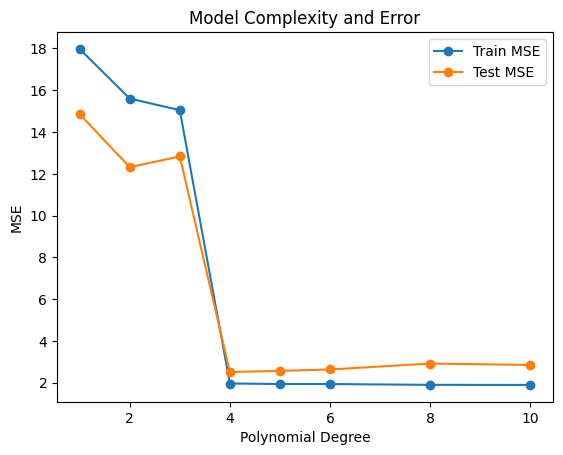

In [10]:
plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Train MSE"
)

plt.plot(
    degrees,
    test_errors,
    marker="o",
    label="Test MSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Model Complexity and Error")
plt.legend()

plt.show()

## Underfitting

Model이 너무 Simple하여 Data의 중요한 Pattern을 충분히 학습하지 못하는 경우를 Underfitting이라고 한다.

Polynomial Regression에서는 Degree가 너무 낮은 경우에 발생할 수 있다.

Underfitting의 일반적인 특징은 다음과 같다.

- Train Error가 크다.
- Test Error도 크다.
- Model이 Data의 Pattern을 충분히 표현하지 못한다.

즉,

> Model Complexity가 부족한 상태

라고 볼 수 있다.

## Overfitting

Model이 Training Data에 지나치게 맞추어진 경우를 Overfitting이라고 한다.

Polynomial Degree가 지나치게 높으면 Training Data의 중요한 Pattern뿐 아니라 Noise까지 따라갈 수 있다.

Overfitting의 일반적인 특징은 다음과 같다.

- Train Error는 매우 작다.
- Test Error는 다시 커질 수 있다.
- Training Data에는 잘 맞지만 새로운 Data에 대한 Prediction이 좋지 않다.

즉,

> Training Data에 지나치게 적응한 상태

라고 볼 수 있다.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


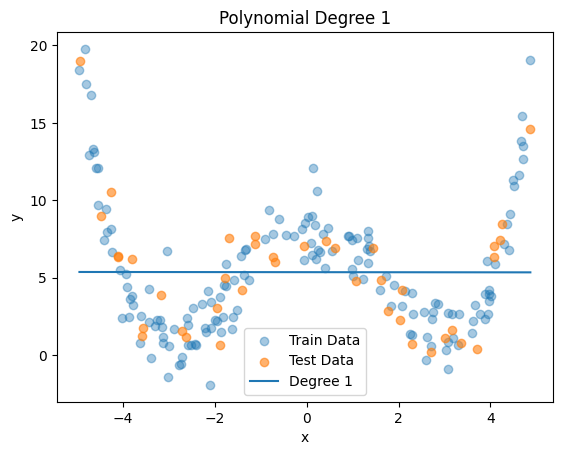

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


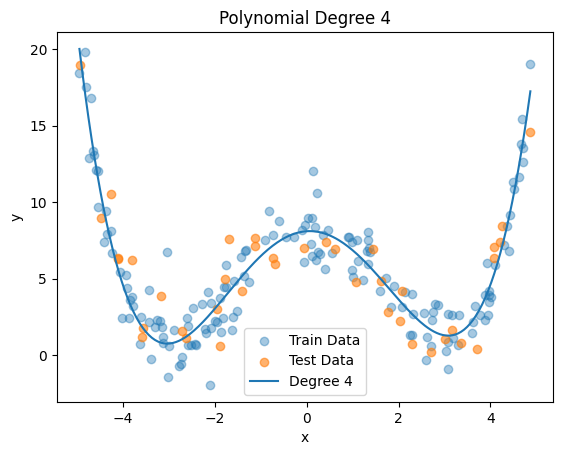

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


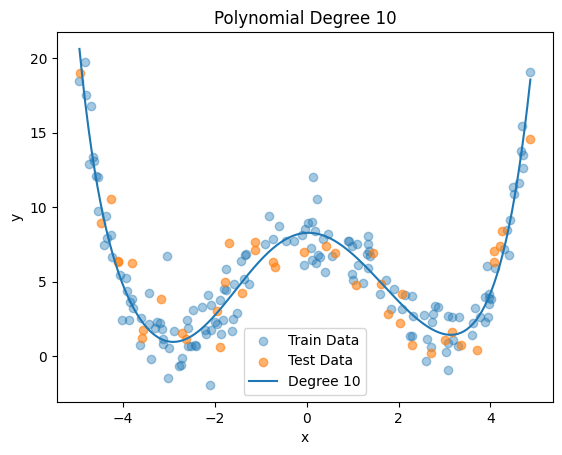

In [16]:
# 낮은 Degree, 적절한 Degree, 높은 Degree 비교
compare_degrees = [1, 4, 10]

x_curve = np.linspace(
    X["x"].min(),
    X["x"].max(),
    300
).reshape(-1, 1)

for degree in compare_degrees:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    X_curve_poly = poly.transform(x_curve)
    y_curve = model.predict(X_curve_poly)

    plt.scatter(
        X_train["x"],
        y_train,
        alpha=0.4,
        label="Train Data"
    )

    plt.scatter(
        X_test["x"],
        y_test,
        alpha=0.6,
        label="Test Data"
    )

    plt.plot(
        x_curve,
        y_curve,
        label=f"Degree {degree}"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Polynomial Degree {degree}")
    plt.legend()

    plt.show()

## Three Situations

Degree가 낮은 Model:

$$
\text{Underfitting}
$$

적절한 Complexity의 Model:

$$
\text{Good Fit}
$$

Degree가 지나치게 높은 Model:

$$
\text{Overfitting}
$$

따라서 Model을 선택할 때 Training Error만 보는 것은 충분하지 않다.

새로운 Data에 대한 Prediction 성능을 함께 확인해야 한다.

## Generalization

Machine Learning Model의 중요한 목적은 Training Data 자체를 정확하게 기억하는 것이 아니다.

Training에 사용하지 않은 새로운 Data에서도 좋은 Prediction을 해야 한다.

이러한 능력을 Generalization이라고 한다.

좋은 Model은

> Training Data에 잘 맞으면서 새로운 Data에도 잘 적용되는 Model

이다.

따라서 Model의 성능을 판단할 때는 Training Performance와 Test Performance를 구분해야 한다.

## Choosing a Model

Polynomial Regression에서 Degree를 높이면 Model Complexity가 증가한다.

그러나 가장 높은 Degree를 선택하는 것이 목적은 아니다.

Degree가 너무 낮으면 Underfitting이 발생할 수 있다.

Degree가 너무 높으면 Overfitting이 발생할 수 있다.

따라서 Train Error와 Test Error를 함께 관찰하여 적절한 Model Complexity를 선택해야 한다.

$$
\text{Too Simple}
\rightarrow
\text{Underfitting}
$$

$$
\text{Appropriate Complexity}
\rightarrow
\text{Good Generalization}
$$

$$
\text{Too Complex}
\rightarrow
\text{Overfitting}
$$

## A Note on Model Selection

이번 강의에서는 Train Data와 Test Data를 이용하여 Model Complexity에 따른 성능 차이를 관찰하였다.

실제 Machine Learning에서는 Model을 선택하는 과정과 최종 성능을 평가하는 과정을 더 엄격하게 분리할 수 있다.

예를 들어 Data를

- Train Data
- Validation Data
- Test Data

로 나누거나 Cross Validation을 사용할 수 있다.

이번 강의에서는 가장 기본적인 Train/Test 개념에 집중한다.

## Assignment - 문제 10

`Input/another3_data.csv`를 Train Data와 Test Data로 나누어 Polynomial Regression을 수행한다.

다음 조건을 사용한다.

- `test_size=0.2`
- `random_state=42`
- Polynomial Degree: 2, 4, 6, 8

다음 질문에 답하시오.

- Degree 2 Model의 Train MSE와 Test MSE를 소수점 셋째 자리까지 적으시오.
- Degree 4 Model의 Train MSE와 Test MSE를 소수점 셋째 자리까지 적으시오.
- Degree 6 Model의 Train MSE와 Test MSE를 소수점 셋째 자리까지 적으시오.
- Degree 8 Model의 Train MSE와 Test MSE를 소수점 셋째 자리까지 적으시오.
- 네 Model 중 Test MSE가 가장 작은 Model의 Degree를 적으시오.
- 네 Model 중 Underfitting이 가장 뚜렷한 Model의 Degree를 적으시오.
- 네 Model 중 Overfitting이 가장 뚜렷한 Model의 Degree를 적으시오.

답만 제출하시오.